Introduction to the PyTorch workflow

- The PyTorch workflow has 6 steps:
  1. Get data ready (turn it into tensors)
  2. Build a model
  3. Fit the model to the data (training)
  4. Make predictions and evaluate the model
  5. Save and load the model
  6. Put it all together
- Training is where the model learns, adjusting its numbers to fit the data
- Saving a model keeps what it learned, so it doesn't need training again
- Chapter 1 builds a straight-line model that learns a weight and a bias from data

In [2]:
import os                                   # load Python's operating-system tools
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # avoid the OpenMP crash on Windows

import torch                                # load PyTorch
from torch import nn                        # load PyTorch's model-building parts
import matplotlib.pyplot as plt             # load the chart-drawing part of matplotlib

In [2]:
%pip install matplotlib 


Note: you may need to restart the kernel to use updated packages.


In [1]:
from torch import nn
import matplotlib.pyplot as plt

### Basics: matplotlib

- matplotlib draws charts; `import matplotlib.pyplot as plt` loads its chart-drawing part
- The x-axis goes across (left to right); the y-axis goes up
- Each point is an (x, y) pair
- `plt.scatter(x, y)` draws dots; `plt.plot(x, y)` draws a connected line
- `plt.xlabel(...)`, `plt.ylabel(...)` and `plt.title(...)` add labels
- `plt.show()` displays the chart
- Charts let us see the data and how close a model's predictions are
- `plt.show()` finishes the current chart; anything drawn after it starts a new chart

A week's temperatures: days [1, 2, 3, 4, 5, 6, 7] and temperatures [31, 29, 35, 33, 30, 28, 34].

Q1. Draw them as dots, with axis labels "Day" and "Temperature".

Q2. Draw the same data as a line with plt.plot. What's the difference in how it looks?

Q3. Add a title to your chart with plt.title("My week").

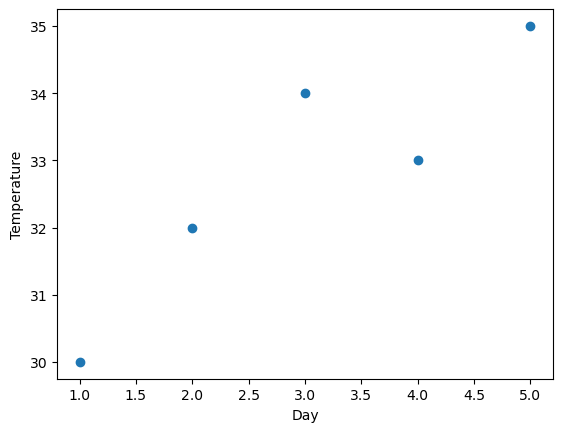

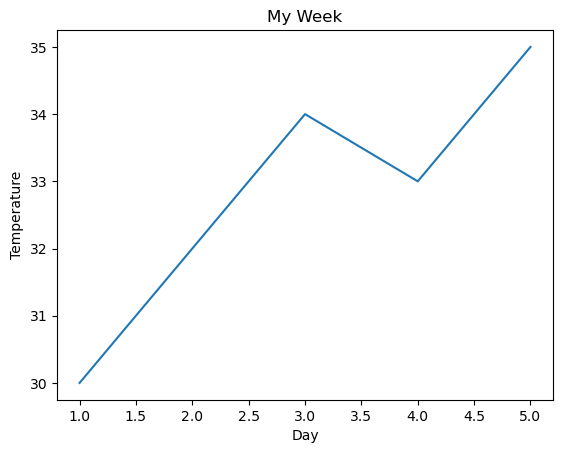

In [4]:
days = [1, 2, 3, 4, 5]
temperatures = [30, 32, 34, 33, 35]
plt.xlabel("Day")
plt.ylabel("Temperature")
plt.scatter(days,temperatures)
plt.show()

plt.xlabel("Day")
plt.ylabel("Temperature")
plt.plot(days, temperatures)
plt.title("My Week")
plt.show()    



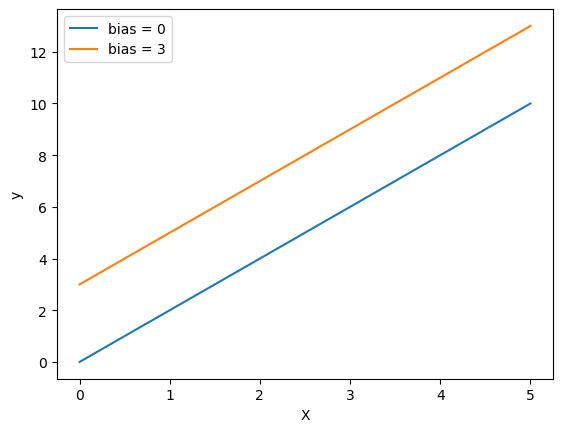

In [5]:
X = torch.arange(0, 6)                       # inputs 0 to 5
plt.plot(X, 2 * X, label="bias = 0")         # weight 2, no bias: starts at (0, 0)
plt.plot(X, 2 * X + 3, label="bias = 3")     # weight 2, bias 3: same tilt, lifted up by 3
plt.xlabel("X")                              # label the x-axis
plt.ylabel("y")                              # label the y-axis
plt.legend()                                 # show which line is which (uses the label= text)
plt.show()                                   # display the chart

asics: Setup, matplotlib and straight lines

**Imports**
- A library is ready-made code; `import` brings it into the notebook
- `import x as y` gives a nickname; `from x import y` takes one part out of a library
- `from torch import nn` gives PyTorch's model-building parts (nn = neural network)
- `import matplotlib.pyplot as plt` loads the chart-drawing part of matplotlib
- After a kernel restart, run the import cell again (otherwise NameError)

**matplotlib**
- `plt.scatter` draws dots; `plt.plot` draws a line
- `plt.xlabel`, `plt.ylabel`, `plt.title` add labels; `plt.legend()` shows line names
- `plt.show()` displays the chart and finishes it

**Straight line**
- `y = weight x X + bias`
- weight tilts the line (how steep); bias lifts it up or down
- Without a bias, every line must pass through (0, 0)
- Linear regression: finding the weight and bias of the line that best fits the data

**How a model learns**
- Labels are the correct answers; predictions are the model's guesses
- Loss is one number showing how wrong the predictions are
- Training: predict, measure the loss, adjust weight and bias, repeat
- Stop when the loss stops going down, or when the test loss starts going up

Q1. From memory, write the setup cell: the OpenMP fix line, plus imports for torch, nn and matplotlib.

Q2. Create km = torch.arange(0, 11) and calculate fare = 15 * km + 25. Plot km vs fare as a line, with axis labels and a title.

Q3. On one chart, draw y = 3 × X and y = 3 × X + 5 for X = torch.arange(0, 6). Give each line a label= and show a legend. What's the same, and what's different?

Q4. On one chart, draw y = 1 × X + 2 and y = 4 × X + 2. Which line is steeper, and where do both lines start?

Q5. By hand: for y = 0.7 × X + 0.3, find y when X = 0.4 and when X = 0.8.

Q6. In words: what's the difference between a label and a prediction? And what is loss?



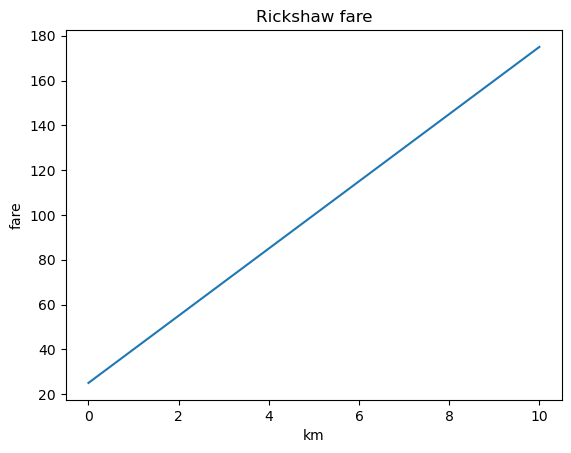

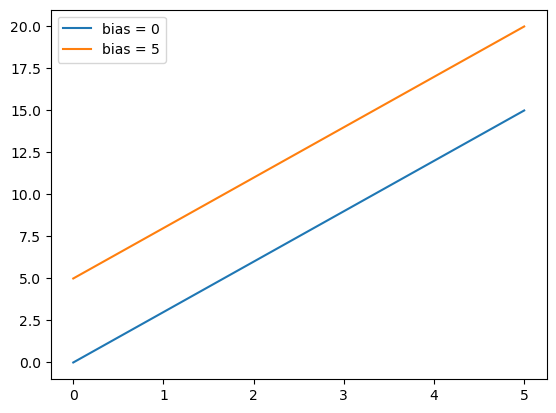

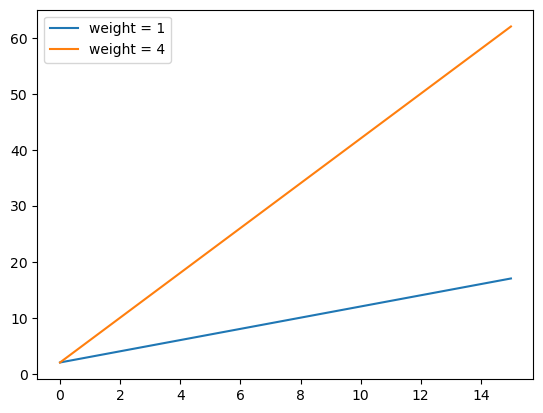

In [8]:
# Q2: rickshaw fare line
km = torch.arange(0, 11)                    # distances from 0 to 10 km
fare = 15 * km + 25                         # fare = 15 per km + 25 starting charge
plt.xlabel("km")                            # label the x-axis
plt.ylabel("fare")                          # label the y-axis
plt.title("Rickshaw fare")                  # add a title
plt.plot(km, fare)                          # draw the fare line
plt.show()                                  # display the chart

# Q3: same weight, different bias
X = torch.arange(0, 6)                      # inputs 0 to 5
plt.plot(X, 3 * X, label="bias = 0")        # weight 3, no bias
plt.plot(X, 3 * X + 5, label="bias = 5")    # weight 3, bias 5: same tilt, 5 higher
plt.legend()                                # show which line is which
plt.show()                                  # display the chart

# Q4: same bias, different weight
X = torch.arange(0, 16)                     # inputs 0 to 15
plt.plot(X, 1 * X + 2, label="weight = 1")  # weight 1, bias 2
plt.plot(X, 4 * X + 2, label="weight = 4")  # weight 4, bias 2: steeper, same start
plt.legend()                                # show which line is which
plt.show()                                  # display the chart

Creating a dataset

- A dataset is inputs (X) with their correct answers (y, the labels)
- We create our own data from a known rule: `y = weight x X + bias`
- Knowing the weight and bias lets us check later whether the model learned them
- Steps: choose weight and bias -> make X with `torch.arange` -> calculate y
- `weight * X + bias` calculates a label for every X at once
- `.unsqueeze(dim=1)` turns X into a column: shape [samples, features]
- The course uses weight 0.7, bias 0.3 and step 0.02, giving 50 data points

Write all the code yourself.

Q1. Choose your own rule: weight = 0.3, bias = 0.9.

Q2. Make X from 0 to 1 with a step of 0.1. Predict first: how many numbers will there be? Print X.

Q3. Calculate y from your rule and print it. Check the first two y values by hand.

Q4. Turn X into a column with unsqueeze. Print its shape. What do the two numbers in the shape mean?

Q5. Plot X and y as dots with plt.scatter, with axis labels. Is it a straight line? What's y at X = 0?

torch.Size([10, 1])
torch.Size([10, 1])
tensor([[0.9000],
        [0.9300]])


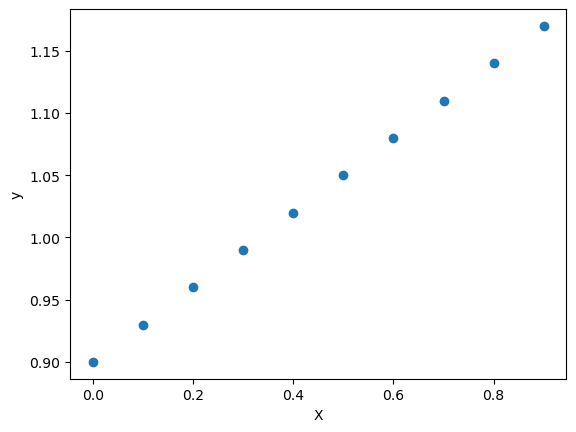

In [10]:
weight = 0.3                                   # the weight we choose
bias = 0.9                                     # the bias we choose

X = torch.arange(0, 1, 0.1).unsqueeze(dim=1)   # 10 inputs from 0 to 0.9, as a column
print(X.shape)                                 # torch.Size([10, 1]): 10 samples, 1 feature each

y = weight * X + bias                          # the label for every input (also a column)
print(y.shape)                                 # torch.Size([10, 1]): same shape as X
print(y[:2])                                   # first two labels: 0.90 and 0.93

plt.scatter(X, y)                              # draw a dot for each (X, y) pair
plt.xlabel("X")                                # label the x-axis
plt.ylabel("y")                                # label the y-axis
plt.show()                                     # display the chart

### Topic 36, Block 1: Why split the data?

- We split data into a training set and a test set
- Training set (about 80%): the model learns from it
- Test set (about 20%): used only to check the model; never seen during training
- Testing on the training data can't show if the model really learned or just memorised
- Generalization: doing well on new, unseen data (the real goal)
- A validation set (practice test) is also common; Chapter 1 uses only training and test

### Topic 36, Block 2: Splitting in code

- Work out the cut position: `train_split = int(0.8 * len(X))`
- `int(...)` turns the result into a whole number, because positions must be whole numbers
- Training set: `X[:train_split]`, `y[:train_split]` (from the start up to the cut)
- Test set: `X[train_split:]`, `y[train_split:]` (from the cut to the end)
- Always cut X and y at the same position, so each input keeps its own label
- `a, b = c, d` creates two variables on one line
- Real projects usually shuffle the data before splitting

Q1. Make your own dataset: weight 0.3, bias 0.9, X from 0 to 1 with step 0.01 (use torch.arange, then unsqueeze). Predict first: how many examples will there be? Split it 80/20, and predict the sizes of the four parts before printing them.

Q2. Print the last training input and the first test input. Are they next to each other?

Q3. Split the same data 70/30 instead. What are the four sizes now?

Q4. In words: what would go wrong if you cut X at position 40 but y at position 30 ?

In [11]:
weight = 0.3                                   # the weight we choose
bias = 0.9                                     # the bias we choose
X = torch.arange(0, 1, 0.01).unsqueeze(dim=1)  # 100 inputs from 0 to 0.99, each on its own row
y = weight * X + bias                          # 100 correct answers

# Q1: 80/20 split
train_split = int(0.8 * len(X))                # 80% of 100 = 80
train_data, train_label = X[:train_split], y[:train_split]  # first 80 inputs and labels
test_data, test_label = X[train_split:], y[train_split:]    # last 20 inputs and labels
print(len(train_data), len(train_label), len(test_data), len(test_label))

# Q2: the last training input and the first test input
print(train_data[-1])                          # the last training input
print(test_data[0])                            # the first test input

# Q3: 70/30 split
train_split_2 = int(0.7 * len(X))              # 70% of 100 = 70
train_data_2, train_label_2 = X[:train_split_2], y[:train_split_2]  # first 70 inputs and labels
test_data_2, test_label_2 = X[train_split_2:], y[train_split_2:]    # last 30 inputs and labels
print(len(train_data_2), len(train_label_2), len(test_data_2), len(test_label_2))

80 80 20 20
tensor([0.7900])
tensor([0.8000])
70 70 30 30


### Topic 36, Block 3a: Visualizing the split

- "Visualize, visualize, visualize": always look at your data on a chart
- `plt.figure(figsize=(10, 7))` makes the chart bigger (width, height)
- In `plt.scatter`: `c=` sets the colour ("b" blue, "g" green, "r" red, or a name like "orange"), `s=` sets the dot size
- `plt.legend(prop={"size": 14})` shows the legend with bigger text
- Training data and test data are drawn in different colours on the same chart
- The model learns from the training dots and must predict the test dots it has never seen


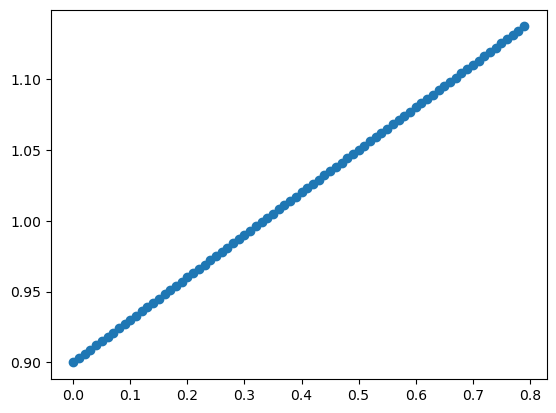

In [13]:
plt.scatter(train_data, train_label)  # a dot for each training example
plt.show()                     # display the chart

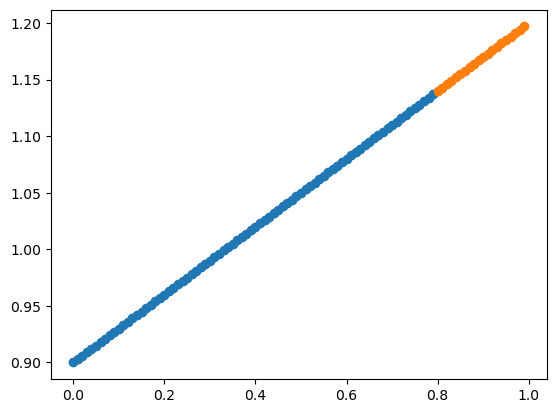

In [15]:
plt.scatter(train_data, train_label)  # training dots
plt.scatter(test_data, test_label)    # test dots (matplotlib picks a different colour automatically)
plt.show()                     # display both together

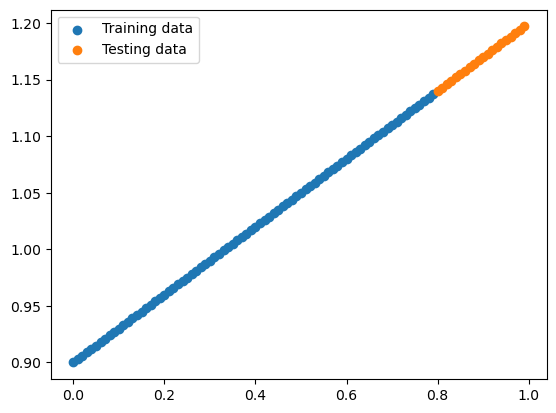

In [16]:
plt.scatter(train_data, train_label, label="Training data")  # training dots, named
plt.scatter(test_data, test_label, label="Testing data")     # test dots, named
plt.legend()                                          # show the names box
plt.show()                                            # display the chart

### Topic 36, Block 3b: plot_predictions function

- A function is a saved recipe: `def` creates it, and calling its name runs it
- Inputs can have default values, used when nothing is given
- `None` means "nothing"; `if x is not None:` runs code only when something was given
- `plot_predictions()` draws the training data, the test data, and predictions if given
- `train_data=train_data`: left = the input's name inside the function, right = my variable used as the default
- Good predictions land on top of the test dots; bad ones are far away
- Run the data cells before the function cell, and re-run it if the data changes

In [17]:
def plot_predictions(train_data=train_data, train_labels=train_label,
                     test_data=test_data, test_labels=test_label,
                     predictions=None):
    plt.scatter(train_data, train_labels, label="Training data")  # draw the training examples
    plt.scatter(test_data, test_labels, label="Testing data")     # draw the test examples
    if predictions is not None:                                    # only if predictions were given...
        plt.scatter(test_data, predictions, label="Predictions")  # ...draw them too
    plt.legend()                                                   # show which colour is which
    plt.show()                                                     # display the chart



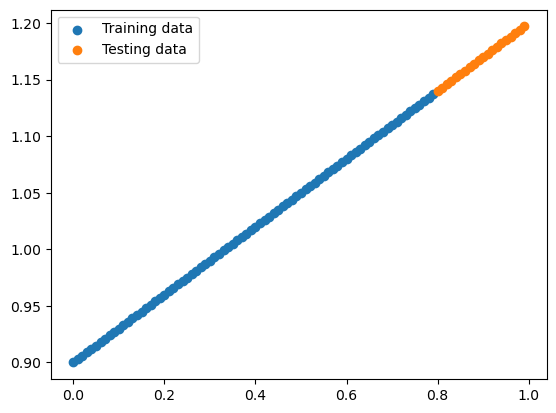

In [18]:
plot_predictions()  # draw the training and test data, no predictions yet

### Backprop concept (intuition)

- Learning loop: predict -> measure the loss -> find the direction -> take a small step -> repeat
- Gradient: which way to change a weight, and how strongly the loss reacts to it
- Negative gradient: increase the weight; positive gradient: decrease the weight
- Update rule: new weight = old weight - learning rate x gradient
- Learning rate: the size of each step (too big overshoots, too small is slow)
- Backpropagation: works out the gradients for all weights at once, going backwards from the loss
- Gradient descent: repeatedly stepping against the gradient so the loss goes down
- In PyTorch, `loss.backward()` does backpropagation for us (Day 3)